In [1]:
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)


d:\mynew\demo_all


# I just want to analyze the data in this notebook, no runmodel

In [2]:
import h5py
def getName(fName):
    hdf = h5py.File(fName, "r")
    all_traj_names = hdf.keys()
    return list(all_traj_names)

HDF_DIR = '.\data\hdf'
HDF_FILE = os.path.join(HDF_DIR, 'aln_demo_21x21.hdf')
print(HDF_FILE)
trajectoryFileName = HDF_FILE
trajectoryName = getName(trajectoryFileName)[-1]
print(trajectoryName)


.\data\hdf\aln_demo_21x21.hdf
results_2025_11_25_13h51m17s


In [3]:
import pypet as pp
trajLoaded = pp.Trajectory(trajectoryName, add_time=False)
trajLoaded.f_load(filename=trajectoryFileName, force=True)
trajLoaded.v_auto_load = True
trajLoaded.f_get_parameters()

{'parameters.warn': <Parameter parameters.warn: 0>,
 'parameters.tau_si': <Parameter parameters.tau_si: 5.0>,
 'parameters.tau_se': <Parameter parameters.tau_se: 2.0>,
 'parameters.tau_ou': <Parameter parameters.tau_ou: 5.0>,
 'parameters.tau_di': <Parameter parameters.tau_di: 1.0>,
 'parameters.tau_de': <Parameter parameters.tau_de: 1.0>,
 'parameters.tauA': <Parameter parameters.tauA: 200.0>,
 'parameters.surfaceSC': <Parameter parameters.surfaceSC: 0.0>,
 'parameters.siiv_init': <Parameter parameters.siiv_init: array([0.00053469])>,
 'parameters.siim_init': <Parameter parameters.siim_init: array([0.29038156])>,
 'parameters.signalV': <Parameter parameters.signalV: 20.0>,
 'parameters.sigmarange': <Parameter parameters.sigmarange: array([0.5       , 0.57142857, 0.64285714, 0.71428571, 0.78571429,
        0.85714286, 0.92857143, 1.        , 1.07142857, 1.14285714,
        1.21428571, 1.28571429, 1.35714286, 1.42857143, 1.5       ,
        1.57142857, 1.64285714, 1.71428571, 1.78571429

In [4]:
trajLoaded.results.aln_results[4].rates_exc[0][5000:6000]

array([1.40059028e-06, 1.41068389e-06, 1.42524548e-06, 1.44330409e-06,
       1.46317360e-06, 1.47945872e-06, 1.49921010e-06, 1.52078887e-06,
       1.54017109e-06, 1.56164699e-06, 1.58395976e-06, 1.60554285e-06,
       1.62687586e-06, 1.64474330e-06, 1.66411954e-06, 1.68521983e-06,
       1.70839041e-06, 1.73567232e-06, 1.76586913e-06, 1.79122461e-06,
       1.81782701e-06, 1.84457790e-06, 1.86727907e-06, 1.88633562e-06,
       1.90220801e-06, 1.91999874e-06, 1.93672034e-06, 1.95347852e-06,
       1.97039764e-06, 1.98892756e-06, 2.00863147e-06, 2.02408672e-06,
       2.03888599e-06, 2.05392837e-06, 2.07181697e-06, 2.08977302e-06,
       2.10984247e-06, 2.12795246e-06, 2.14580361e-06, 2.16632232e-06,
       2.18478219e-06, 2.20174186e-06, 2.21655688e-06, 2.22978174e-06,
       2.24433574e-06, 2.25878260e-06, 2.27580168e-06, 2.29547475e-06,
       2.31623875e-06, 2.33371438e-06, 2.35348204e-06, 2.37561480e-06,
       2.39770208e-06, 2.42199072e-06, 2.45440956e-06, 2.49143056e-06,
      

In [5]:
import pandas as pd
nResults = len(trajLoaded.f_get_run_names())
dt = trajLoaded.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = trajLoaded.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [6]:
print(dt)

0.1


In [7]:
from joblib import Parallel, delayed 
import multiprocessing 
import numpy as np
from tqdm import *
num_cores = multiprocessing.cpu_count()

'''
plot_results = np.array([])
for rInd in range(len(dfResults)):
    max_rate = np.max(trajLoaded.results.aln_results[rInd].rates_exc[0]*1000)
    dfResults.loc[rInd, "max_rate"] = max_rate 
    plot_results = np.append(plot_results, max_rate)
'''
up_state = -int(1000/dt)
def cal_max(i):
    max_rate = np.max(trajLoaded.results.aln_results[i].rates_exc[0][up_state:]*1000)
    return max_rate

plot_results = Parallel(n_jobs=num_cores-4)(delayed(cal_max)(i) for i in tqdm(range(len(dfResults))))
# plot_results = Parallel(n_jobs=num_cores-14)(delayed(cal_max)(i) for i in range(10))

print(plot_results)


100%|██████████| 2601/2601 [12:23<00:00,  3.50it/s]


[0.23007449060835852, 0.12050853729207574, 0.10405589771067855, 0.0533747317880395, 0.023568447634854512, 0.01877569340797093, 0.011195382367024437, 0.00466233730322821, 0.006142510299598862, 0.00116611972283698, 0.0007248149271807158, 0.00035243574665533647, 0.00018235294169682058, 5.3867817459367976e-05, 1.676387589480213e-05, 8.756477200706434e-06, 1.9930684095147738e-06, 8.256467356936699e-07, 2.467534126516197e-07, 2.855380769926561e-08, 5.9413274806544675e-09, 1.4184805489433709e-09, 1.301763734786133e-09, 7.986473522825508e-10, 7.979078236562961e-10, 4.267916951268029e-10, 3.7258577902372305e-10, 2.516823635013516e-10, 2.1179268906034388e-10, 1.3517311045459415e-10, 7.26942758161761e-11, 4.422638751512407e-11, 3.786946554728084e-11, 2.823291096646156e-11, 1.7694820767298542e-11, 8.911883238872868e-12, 1.1636882133295195e-11, 3.3745466261917965e-12, 2.8353325381103773e-12, 2.6579323022736908e-12, 2.2899944431040434e-12, 2.072943928922542e-12, 1.7634694420778013e-12, 1.45221954112

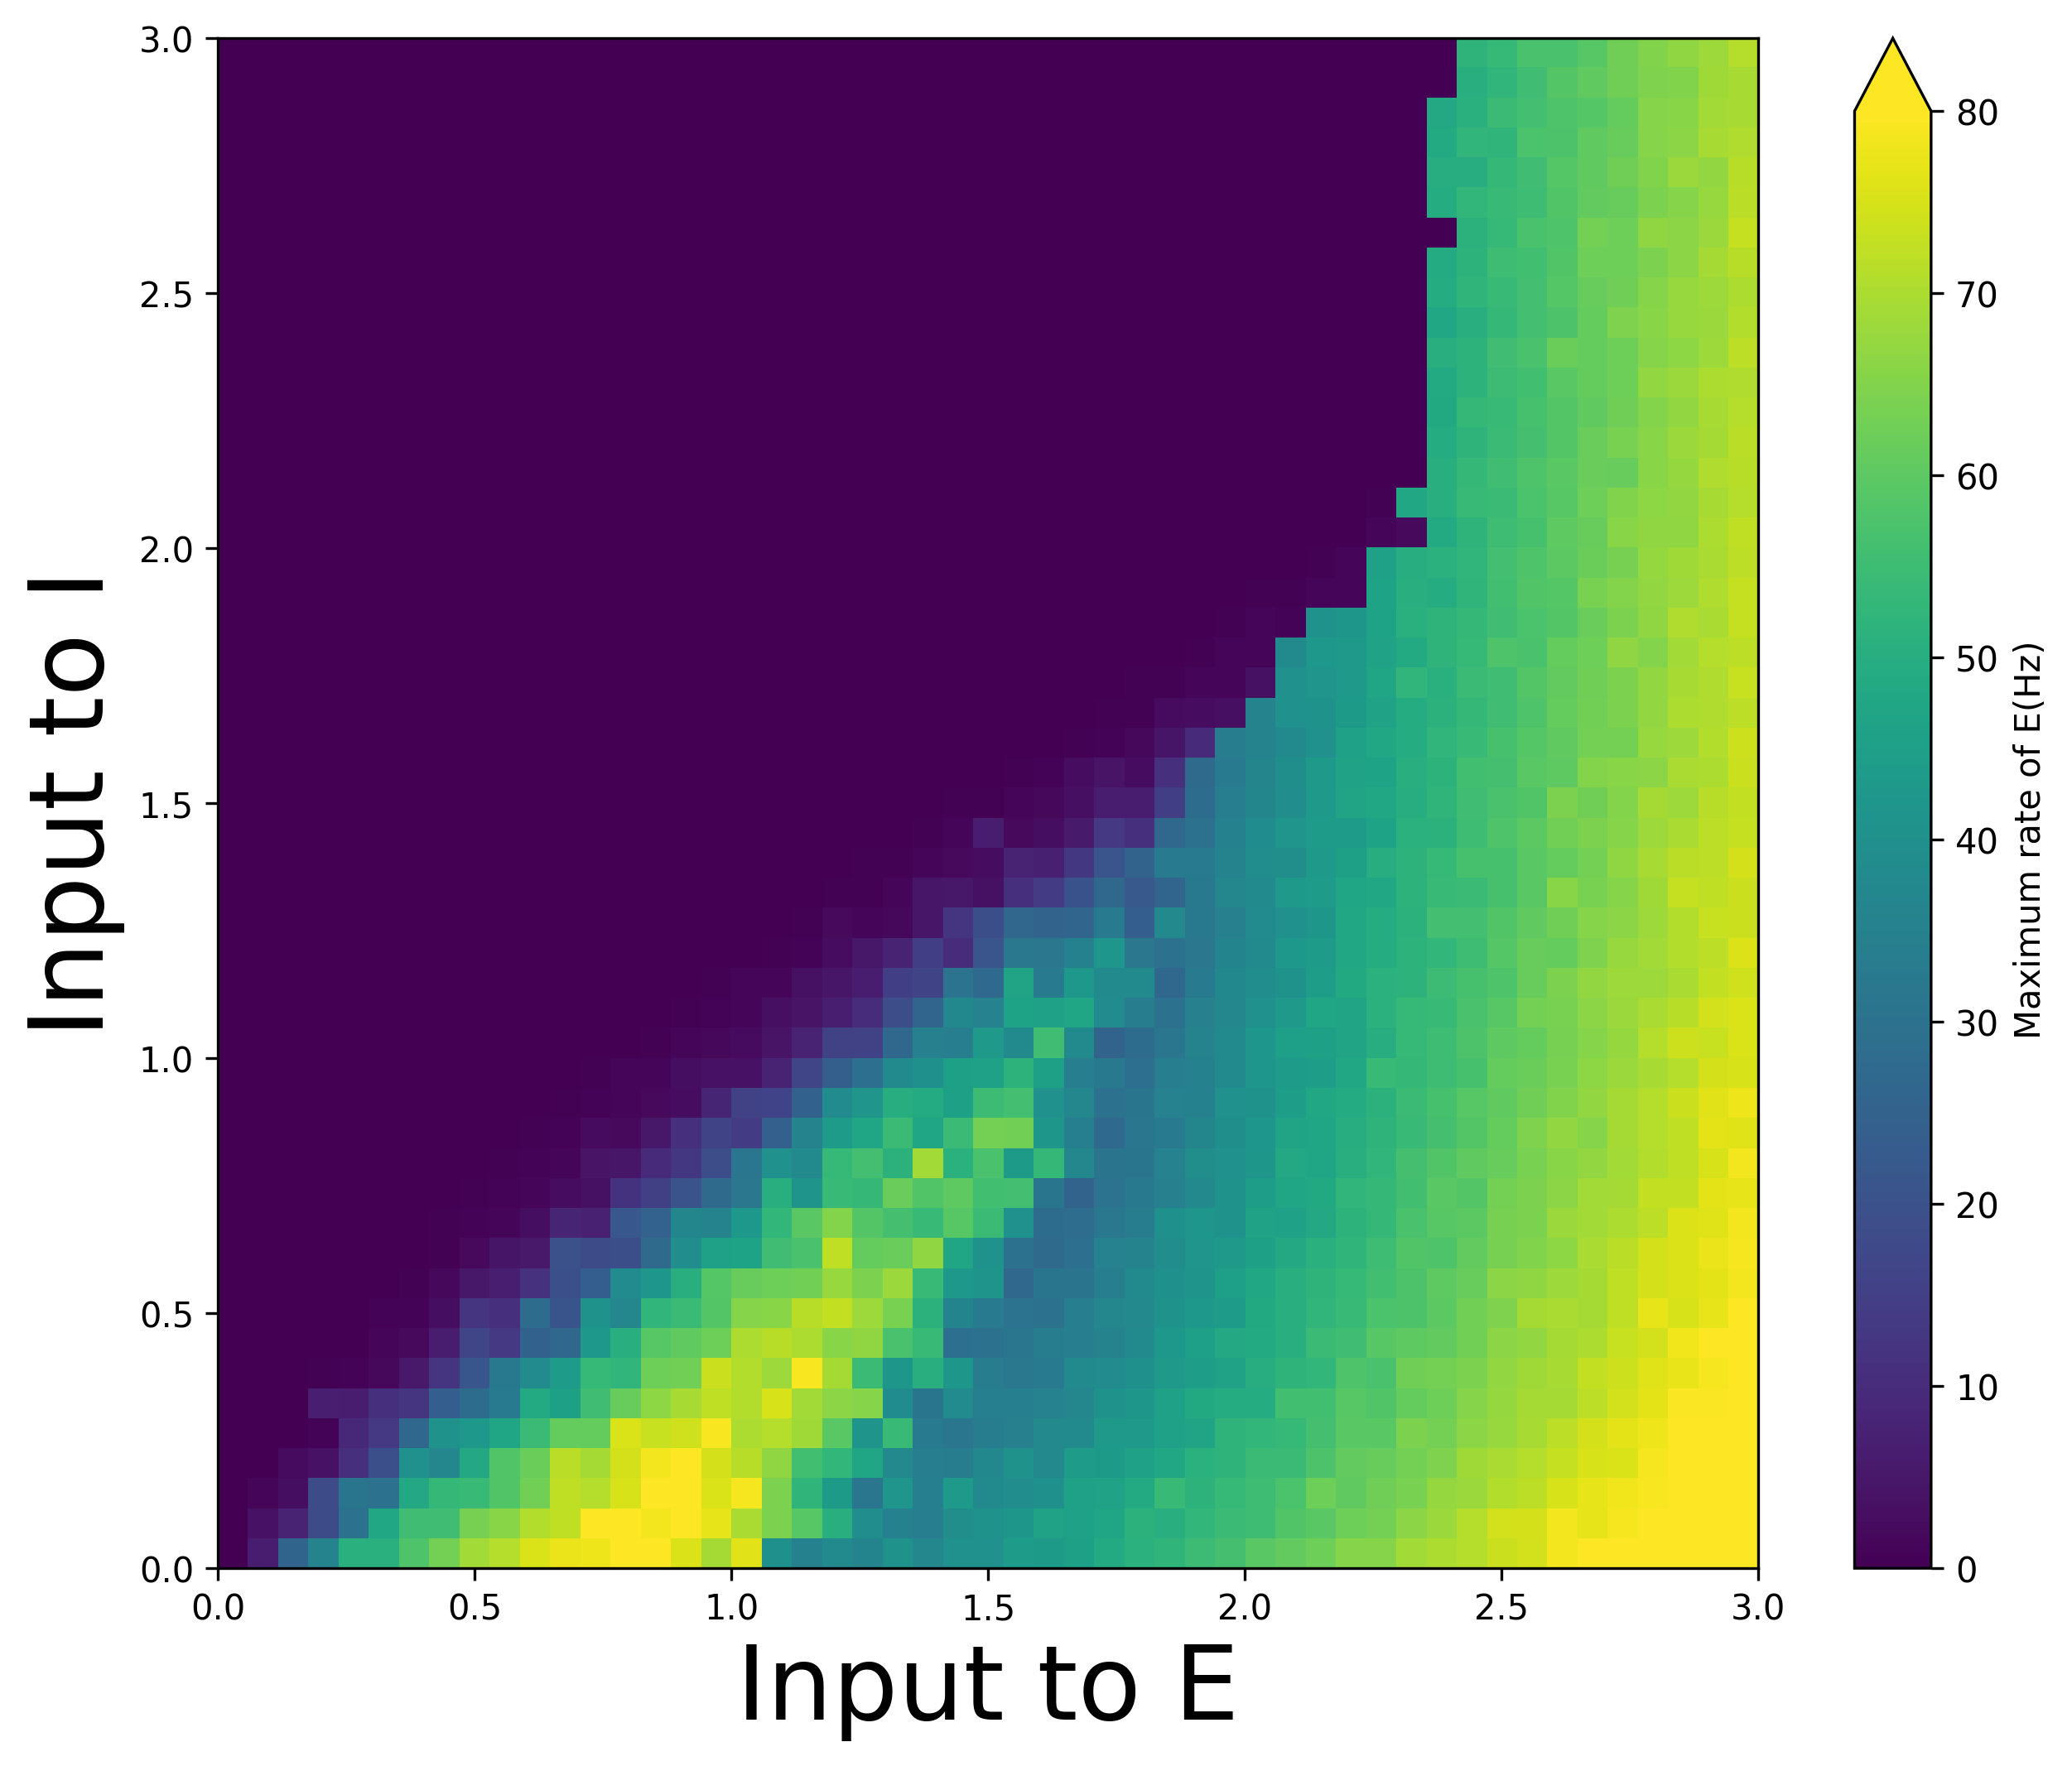

In [8]:


import matplotlib.pyplot as plt

mues = np.unique(dfResults['mue_ext_mean'])
muis = np.unique(dfResults['mui_ext_mean'])
plot_results_matrix = np.reshape(plot_results, (len(mues), len(muis))).T

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[mues[0], mues[-1], muis[0], muis[-1]])

plt.xlabel("Input to E", fontsize=30)
plt.ylabel("Input to I", fontsize=30)
plt.clim(0, 80)
cbar = plt.colorbar(label="Maximum rate of E(Hz)", extend='max')
plt.show()

In [9]:
a = np.array([1,2])
b = 14
np.append(a,b)
a

array([1, 2])